# Named Entity Recognition
In this notebook we'll explore how we can use Deep Learning for sequence labelling tasks, specifically, Named Entity Recognition (NER). First, we will go through a simple RNN model as the code base.

## Data
For our experiments we'll use the Dutch CoNLL-2002 data which has four kinds of named entities (people, locations, organizations and miscellaneous entities) and comes split into a training, development and test set.

In [ ]:
import nltk
import random
nltk.download('conll2002')

random.seed(42)
train_sents = random.sample(list(nltk.corpus.conll2002.iob_sents('ned.train')), 10000)
dev_sents = list(nltk.corpus.conll2002.iob_sents('ned.testa'))
test_sents = list(nltk.corpus.conll2002.iob_sents('ned.testb'))

train_sents[:3]

[nltk_data] Downloading package conll2002 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2002.zip.


[[('Daarnaast', 'Adv', 'O'),
  ('brengt', 'V', 'O'),
  ('het', 'Art', 'O'),
  ('TV', 'N', 'B-MISC'),
  ('1-magazine', 'Adj', 'I-MISC'),
  ('1000', 'Num', 'B-MISC'),
  ('Zonnen', 'N', 'I-MISC'),
  ('en', 'Conj', 'I-MISC'),
  ('Garnalen', 'N', 'I-MISC'),
  ('drie', 'Num', 'O'),
  ('weken', 'N', 'O'),
  ('lang', 'Adj', 'O'),
  ('elke', 'Pron', 'O'),
  ('dag', 'N', 'O'),
  ('een', 'Art', 'O'),
  ('randreportage', 'Adj', 'O'),
  ('over', 'Prep', 'O'),
  ('allerlei', 'Pron', 'O'),
  ('boeiende', 'V', 'O'),
  ('mensen', 'N', 'O'),
  ('en', 'Conj', 'O'),
  ('dingen', 'N', 'O'),
  ('in', 'Prep', 'O'),
  ('de', 'Art', 'O'),
  ('Tour', 'N', 'B-MISC'),
  ('.', 'Punc', 'O')],
 [('pagina', 'N', 'O')],
 [('Algemeen', 'Adj', 'O')]]

Next, we're going to preprocess the data. For this we use the torchtext Python library, which has a number of handy utilities for preprocessing natural language. We process our data to a **Dataset** that consists of **Examples**. Each of these examples has two fields: a **text** field and a **label** field. Both contain sequential information (the sequence of tokens, and the sequence of labels). We don't have to tokenize this information anymore, as the CONLL data has already been tokenized for us.

In [ ]:
!pip install torchtext==0.6
from torchtext.data import Example
from torchtext.data import Field, Dataset

text_field = Field(sequential=True, tokenize=lambda x:x, include_lengths=True) # Default behaviour is to tokenize by splitting
label_field = Field(sequential=True, tokenize=lambda x:x, is_target=True)

def read_data(sentences):
    examples = []
    fields = {'sentence_labels': ('labels', label_field),
              'sentence_tokens': ('text', text_field)}

    for sentence in sentences:
        tokens = [t[0] for t in sentence]
        labels = [t[2] for t in sentence]

        e = Example.fromdict({"sentence_labels": labels, "sentence_tokens": tokens},
                             fields=fields)
        examples.append(e)

    return Dataset(examples, fields=[('labels', label_field), ('text', text_field)])

train_data = read_data(train_sents)
dev_data = read_data(dev_sents)
test_data = read_data(test_sents)

print(train_data.fields)
print(train_data[0].text)
print(train_data[0].labels)

print("Train:", len(train_data))
print("Dev:", len(dev_data))
print("Test:", len(test_data))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 1.9 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl (176.2 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-man

Next, we build a vocabulary for both fields. This vocabulary allows us to map every word and label to their index. One index is kept for unknown words, another one for padding.

In [ ]:
VOCAB_SIZE = 20000

text_field.build_vocab(train_data, max_size=VOCAB_SIZE)
label_field.build_vocab(train_data)

In [ ]:
vocab = label_field.vocab
print(vocab.itos)

['<unk>', '<pad>', 'O', 'B-PER', 'B-LOC', 'B-MISC', 'I-PER', 'B-ORG', 'I-MISC', 'I-ORG', 'I-LOC']


## Training
If we're on a machine with a CUDA-enabled GPU, we'd like to use this GPU for training and testing. If not, we'll just use the CPU. The check below allows us to write code that works on both CPU and GPU.

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


Another convenient class in Torchtext is the BucketIterator. This iterator creates batches of similar-length examples in the data. It also takes care of mapping the words and labels to the correct indices in their vocabularies, and pads the sentences so that they all have the same length. The Bucketiterator creates batches of similar-length examples to minimize the amount of padding.

In [ ]:
from torchtext.data import BucketIterator

BATCH_SIZE = 32
train_iter = BucketIterator(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True,
                            sort_key=lambda x: len(x.text), sort_within_batch=True)
dev_iter = BucketIterator(dataset=dev_data, batch_size=BATCH_SIZE,
                          sort_key=lambda x: len(x.text), sort_within_batch=True)
test_iter = BucketIterator(dataset=test_data, batch_size=BATCH_SIZE,
                           sort_key=lambda x: len(x.text), sort_within_batch=True)

## Model

Next, we create our BiLSTM model. It consists of four layers:

* An embedding layer that maps one-hot word vectors to dense word embeddings. These embeddings are either pretrained or trained from scratch.
* A bidirectional LSTM layer that reads the text both front to back and back to front. For each word, this LSTM produces two output vectors of dimensionality hidden_dim, which are concatenated to a vector of 2*hidden_dim.
* A dropout layer that helps us avoid overfitting by dropping a certain percentage of the items in the LSTM output.
* A dense layer that projects the LSTM output to an output vector with a dimensionality equal to the number of labels.

We initialize these layers in the `__init__` method, and put them together in the `forward` method.

In [ ]:
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

class BiLSTMTagger(nn.Module):

    def __init__(self, embedding_dim, hidden_dim, vocab_size, output_size):
        super(BiLSTMTagger, self).__init__()

        # 1. Embedding Layer
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)

        # 2. LSTM Layer
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, bidirectional=True, num_layers=1)

        # 3. Optional dropout layer
        self.dropout_layer = nn.Dropout(p=0.5)

        # 4. Dense Layer
        self.hidden2tag = nn.Linear(2*hidden_dim, output_size)

    def forward(self, batch_text, batch_lengths):

        embeddings = self.embeddings(batch_text)
        batch_lengths = batch_lengths.cpu().long()

        packed_seqs = pack_padded_sequence(embeddings, batch_lengths)
        lstm_output, _ = self.lstm(packed_seqs)
        lstm_output, _ = pad_packed_sequence(lstm_output)
        lstm_output = self.dropout_layer(lstm_output)

        logits = self.hidden2tag(lstm_output)
        return logits

## Training
Then we need to train this model. This involves taking a number of decisions:

* We pick a loss function (or criterion) to quantify how far away the model predictions are from the correct output. For multiclass tasks such as Named Entity Recognition, a standard loss function is the Cross-Entropy Loss, which here measures the difference between two multinomial probability distributions. PyTorch's `CrossEntropyLoss` does this by first applying a softmax to the last layer of the model to transform the output scores to probabilities, and then computing the cross-entropy between the predicted and correct probability distributions. The `ignore_index` parameter allows us to mask the padding items in the training data, so that these do not contribute to the loss.
* Next, we need to choose an optimizer. For many NLP problems, the Adam optimizer is a good first choice. Adam is a variation of Stochastic Gradient Descent with several advantages: it maintains per-parameter learning rates and adapts these learning rates based on how quickly the values of a specific parameter are changing (or, how large its average gradient is).

Then the actual training starts. This happens in several epochs. During each epoch, we show all of the training data to the network, in the batches produced by the BucketIterators we created above. Before we show the model a new batch, we set the gradients of the model to zero to avoid accumulating gradients across batches. Then we let the model make its predictions for the batch. We do this by taking the output, and finding out what label received the highest score, using the `torch.max` method. We then compute the loss with respect to the correct labels. `loss.backward()` then computes the gradients for all model parameters; `optimizer.step()` performs an optimization step.

When we have shown all the training data in an epoch, we perform the precision, recall and F-score on the training data and development data. Note that we compute the loss for the development data, but we do not optimize the model with it. Whenever the F-score on the development data is better than before, we save the model. If the F-score is lower than the minimum F-score we've seen in the past few epochs (we call this number the patience), we stop training.

In [ ]:
import torch.optim as optim
from tqdm import tqdm_notebook as tqdm
from sklearn.metrics import precision_recall_fscore_support, classification_report


def train(model, train_iter, dev_iter, batch_size, max_epochs, num_batches, patience, output_path):
    criterion = nn.CrossEntropyLoss(ignore_index=1)  # we mask the <pad> labels
    optimizer = optim.Adam(model.parameters())

    train_f_score_history = []
    dev_f_score_history = []
    no_improvement = 0
    for epoch in range(max_epochs):

        total_loss = 0
        predictions, correct = [], []
        for batch in tqdm(train_iter, total=num_batches, desc=f"Epoch {epoch}"):
            optimizer.zero_grad()

            text_length, cur_batch_size = batch.text[0].shape

            pred = model(batch.text[0].to(device), batch.text[1].to(device)).view(cur_batch_size*text_length, NUM_CLASSES)
            gold = batch.labels.to(device).view(cur_batch_size*text_length)

            loss = criterion(pred, gold)

            total_loss += loss.item()

            loss.backward()
            optimizer.step()

            _, pred_indices = torch.max(pred, 1)

            predicted_labels = list(pred_indices.cpu().numpy())
            correct_labels = list(batch.labels.view(cur_batch_size*text_length).numpy())

            predictions += predicted_labels
            correct += correct_labels

        train_scores = precision_recall_fscore_support(correct, predictions, average="micro")
        train_f_score_history.append(train_scores[2])

        print("Total training loss:", total_loss)
        print("Training performance:", train_scores)

        total_loss = 0
        predictions, correct = [], []
        for batch in dev_iter:

            text_length, cur_batch_size = batch.text[0].shape

            pred = model(batch.text[0].to(device), batch.text[1].to(device)).view(cur_batch_size * text_length, NUM_CLASSES)
            gold = batch.labels.to(device).view(cur_batch_size * text_length)
            loss = criterion(pred, gold)
            total_loss += loss.item()

            _, pred_indices = torch.max(pred, 1)
            predicted_labels = list(pred_indices.cpu().numpy())
            correct_labels = list(batch.labels.view(cur_batch_size*text_length).numpy())

            predictions += predicted_labels
            correct += correct_labels

        dev_scores = precision_recall_fscore_support(correct, predictions, average="micro")

        print("Total development loss:", total_loss)
        print("Development performance:", dev_scores)

        dev_f = dev_scores[2]
        if len(dev_f_score_history) > patience and dev_f < max(dev_f_score_history):
            no_improvement += 1

        elif len(dev_f_score_history) == 0 or dev_f > max(dev_f_score_history):
            print("Saving model.")
            torch.save(model, output_path)
            no_improvement = 0

        if no_improvement > patience:
            print("Development F-score does not improve anymore. Stop training.")
            dev_f_score_history.append(dev_f)
            break

        dev_f_score_history.append(dev_f)

    return train_f_score_history, dev_f_score_history

## Test
When we test the model, we basically take the same steps as in the evaluation on the development data above: we get the predictions, remove the masked items and print a classification report.

In [ ]:
def test(model, test_iter, batch_size, labels, target_names):

    total_loss = 0
    predictions, correct = [], []
    for batch in test_iter:

        text_length, cur_batch_size = batch.text[0].shape

        pred = model(batch.text[0].to(device), batch.text[1].to(device)).view(cur_batch_size * text_length, NUM_CLASSES)
        gold = batch.labels.to(device).view(cur_batch_size * text_length)

        _, pred_indices = torch.max(pred, 1)
        predicted_labels = list(pred_indices.cpu().numpy())
        correct_labels = list(batch.labels.view(cur_batch_size*text_length).numpy())

        predictions += predicted_labels
        correct += correct_labels

    print(classification_report(correct, predictions, labels=labels, target_names=target_names))

## Implementation
Now we can start the actual training. We set the embedding dimension to 300 (the dimensionality of the FastText embeddings), and pick a hidden dimensionality for each component of the BiLSTM (which will therefore output 512-dimensional vectors). The number of classes (the length of the vocabulary of the label field) will become the dimensionality of the output layer. Finally, we also compute the number of batches in an epoch, so that we can show a progress bar.

In [ ]:
import math

EMBEDDING_DIM = 300
HIDDEN_DIM = 256
NUM_CLASSES = len(label_field.vocab)
MAX_EPOCHS = 5
PATIENCE = 3
OUTPUT_PATH = "/tmp/bilstmtagger"
num_batches = math.ceil(len(train_data) / BATCH_SIZE)

tagger = BiLSTMTagger(EMBEDDING_DIM, HIDDEN_DIM, VOCAB_SIZE+2, NUM_CLASSES)

train_f, dev_f = train(tagger.to(device), train_iter, dev_iter, BATCH_SIZE, MAX_EPOCHS,
                       num_batches, PATIENCE, OUTPUT_PATH)

<ipython-input-35-c1bc8053df99>:17: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for batch in tqdm(train_iter, total=num_batches, desc=f"Epoch {epoch}"):


Epoch 0:   0%|          | 0/313 [00:00<?, ?it/s]

Total training loss: 146.32575462386012
Training performance: (0.6243274404304381, 0.6243274404304381, 0.6243274404304381, None)
Total development loss: 40.851508331950754
Development performance: (0.8889834003505516, 0.8889834003505516, 0.8889834003505516, None)
Saving model.


<ipython-input-35-c1bc8053df99>:17: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for batch in tqdm(train_iter, total=num_batches, desc=f"Epoch {epoch}"):


Epoch 1:   0%|          | 0/313 [00:00<?, ?it/s]

...

Epoch 3:   0%|          | 0/313 [00:00<?, ?it/s]

Total training loss: 16.10101052862592
Training performance: (0.668395127118644, 0.668395127118644, 0.668395127118644, None)
Total development loss: 43.47655884872074
Development performance: (0.9048871017630683, 0.9048871017630683, 0.9048871017630683, None)
Saving model.


<ipython-input-35-c1bc8053df99>:17: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for batch in tqdm(train_iter, total=num_batches, desc=f"Epoch {epoch}"):


Epoch 4:   0%|          | 0/313 [00:00<?, ?it/s]

Total training loss: 7.896443202829687
Training performance: (0.7181112111661414, 0.7181112111661414, 0.7181112111661413, None)
Total development loss: 45.633493106244714
Development performance: (0.905815032477575, 0.905815032477575, 0.9058150324775749, None)
Saving model.


## Plot
Let's now plot the evolution of the F-score on our training and development set, to visually evaluate if training went well. If it did, the training F-score should first increase suddenly, then more gradually. The development F-score will increase during the first few epochs, but at some point it will start to decrease again. That's when the model starts overfitting. This is where we abandon training, and why we only save the model when we have reached an optimal F-score on the development data.

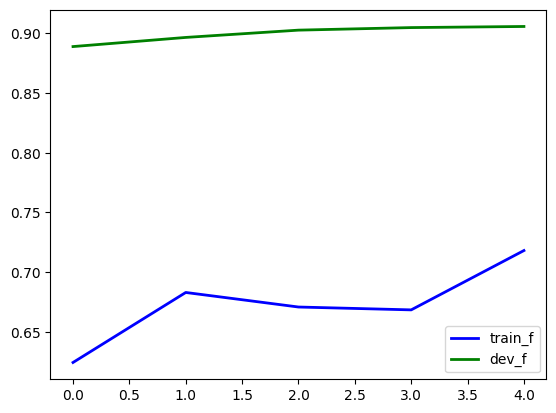

In [ ]:
%matplotlib notebook
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd

# Data
df = pd.DataFrame({'epochs': range(0,len(train_f)),
                  'train_f': train_f,
                   'dev_f': dev_f})

# multiple line plot
plt.plot('epochs', 'train_f', data=df, color='blue', linewidth=2)
plt.plot('epochs', 'dev_f', data=df, color='green', linewidth=2)
plt.legend()
plt.show()

Before we test our model on the test data, we have to run its `eval()` method. This will put the model in eval mode, and deactivate dropout layers and other functionality that is only useful in training.

In [ ]:
tagger = torch.load(OUTPUT_PATH)
tagger.eval()

BiLSTMTagger(
  (embeddings): Embedding(20002, 300)
  (lstm): LSTM(300, 256, bidirectional=True)
  (dropout_layer): Dropout(p=0.5, inplace=False)
  (hidden2tag): Linear(in_features=512, out_features=11, bias=True)
)

## Evaluation
Finally, we test the model. You'll notice its performance is low. Designing a competitive neural network takes considerably more effort than we put in here.

In [ ]:
labels = label_field.vocab.itos[3:]
labels = sorted(labels, key=lambda x: x.split("-")[-1])
label_idxs = [label_field.vocab.stoi[l] for l in labels]

test(tagger, test_iter, BATCH_SIZE, labels = label_idxs, target_names = labels)

              precision    recall  f1-score   support

       B-LOC       0.88      0.52      0.66       774
       I-LOC       0.92      0.24      0.39        49
      B-MISC       0.80      0.45      0.57      1187
      I-MISC       0.68      0.21      0.32       410
       B-ORG       0.88      0.36      0.51       882
       I-ORG       0.96      0.38      0.55       551
       B-PER       0.77      0.38      0.51      1098
       I-PER       0.94      0.32      0.48       807

   micro avg       0.84      0.39      0.53      5758
   macro avg       0.85      0.36      0.50      5758
weighted avg       0.85      0.39      0.53      5758



## **Task**

Now it is your time to adjust the above code and come up with strategies to improve the performance on NER. Provide your revision to the original model and explain what you have done. Complete the four tasks below by directly editing on the code base and printing your final training/testing performances.





### **Task 1**
Refine the original code to remove the effect of irrelevant tokens (i.e., padded tokens) when evaluating the results (during both training and testing).

### **Task 2**
Do you think the current evaluation metric (`precision_recall_fscore_support`, `classification_report`) makes sense? If not, can you give a more approriate evaluation function for NER to replace the above and print the updated evaluation on test set? Hint: NER task is based on complete entities as single units. (You are allowed to search for an approriate built-in package.)

**Explain your action here**:

### **Task 3**
Replace random word embedding initialization with pretrained word embeddings such as **word2vec**, **Glove** or **FastText**.

### **Task 4**
Try other possible strategies (other than changing the hyper-parameters, preferably model architecture change) to improve the performance.

**Explain what you have done and why you think it is beneficial here**: